# CTGAN SYNTHETIC DATA GENERATION

This notebook uses Generative AI (CTGAN) to generate synthetic fraud transactions.

The goal is to solve class imbalance in the dataset by creating realistic fraud samples.

---

IMPORT LIBRARIES

In [4]:
import pandas as pd
import numpy as np

UPLOAD DATASET

In [3]:
from google.colab import files

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

data = pd.read_csv(file_name)
data.head()

Saving creditcard.csv to creditcard.csv


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


SELECT FRAUD DATA

In [5]:
# Filter only fraud transactions
fraud_data = data[data['Class'] == 1]

print("Fraud samples:", len(fraud_data))

Fraud samples: 492


INSTALL CTGAN

In [6]:
!pip install ctgan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 55.5 MB/s eta 0:00:00


IMPORT CTGAN

In [7]:
from ctgan import CTGAN

TRAIN MODEL

In [8]:
ctgan = CTGAN(epochs=100)

ctgan.fit(fraud_data)

GENERATE SYNTHETIC DATA

In [9]:
synthetic_fraud = ctgan.sample(5000)

synthetic_fraud.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,69248.128811,-19.806789,0.593542,7.088085,3.548946,-5.916852,-4.275606,-6.295162,-7.113381,-5.852717,...,4.123318,0.003783,-2.049237,-0.268596,-0.351980,0.074743,-1.201115,0.731290,36.383638,1
1,-3552.823776,1.239827,4.898231,-5.396934,1.857657,0.437884,-4.653192,-23.531615,0.631649,-1.344060,...,-1.574328,0.708784,-1.817622,-1.118471,-3.000395,0.295092,-0.295776,0.200686,-50.119570,1
2,-36994.737077,-3.329193,-2.691828,-5.687979,0.731070,-15.951568,-5.305085,-12.034358,-1.418283,-7.136458,...,-0.834801,-0.004105,-2.448913,-1.313887,-0.878705,-1.097918,-0.722539,-0.122383,-57.650437,1
3,61280.293569,1.701966,2.330202,-8.423526,9.127869,-1.369003,-3.002821,-8.075957,-0.704688,-1.071322,...,-2.121931,-1.827733,-1.181661,-0.045661,-1.609398,-0.412728,0.462256,-0.002726,-7.438111,1
4,29059.345873,3.763379,0.918809,-0.631882,10.992330,-1.712075,-5.276796,-13.813234,1.032879,-5.082069,...,-1.127281,-0.955548,-0.450553,0.341041,-0.552460,-1.778756,-0.019019,0.602332,105.555576,1


VALIDATE DATA

In [10]:
print("Original fraud data shape:", fraud_data.shape)
print("Synthetic data shape:", synthetic_fraud.shape)

Original fraud data shape: (492, 31)
Synthetic data shape: (5000, 31)


SAVE SYNTHETIC DATA

In [14]:
synthetic_fraud.to_csv("synthetic_fraud.csv", index=False)

In [15]:
from google.colab import files
files.download('synthetic_fraud.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

VISUAL CHECK

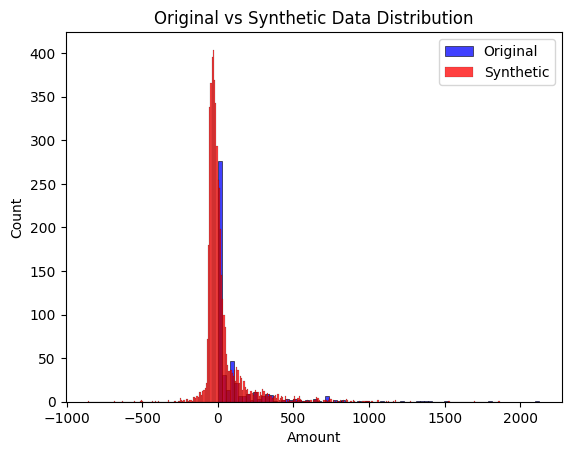

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(fraud_data['Amount'], label='Original', color='blue')
sns.histplot(synthetic_fraud['Amount'], label='Synthetic', color='red')

plt.legend()
plt.title("Original vs Synthetic Data Distribution")
plt.show()

## CONCLUSION

CTGAN successfully generated synthetic fraud transactions.

This synthetic data will be used to improve model performance by balancing the dataset.

---